<a href="https://colab.research.google.com/github/MTG19/House-Price-Prediction/blob/main/HousePricePrediction.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# House Price Prediction – Advanced Regression Analysis
**Exploring features, preprocessing, and predictive modeling to estimate house prices**

This project predicts house prices using a real-world dataset (`HousePricePrediction.xlsx`).
It demonstrates:
- Data cleaning & preprocessing
- Feature engineering
- Multiple regression modeling approaches (Linear, Ridge, Polynomial)
- Encoding strategies for categorical variables
- Feature selection and hyperparameter optimization
- Model comparison and performance evaluation

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.linear_model import Ridge
from sklearn.preprocessing import PolynomialFeatures
from sklearn.model_selection import GridSearchCV
from category_encoders import TargetEncoder
from sklearn.feature_selection import SelectKBest, f_regression


# EDA and Preprocessing

In [ ]:
df = pd.read_excel("HousePricePrediction.xlsx")

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2919 entries, 0 to 2918
Data columns (total 13 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   Id            2919 non-null   int64  
 1   MSSubClass    2919 non-null   int64  
 2   MSZoning      2915 non-null   object 
 3   LotArea       2919 non-null   int64  
 4   LotConfig     2919 non-null   object 
 5   BldgType      2919 non-null   object 
 6   OverallCond   2919 non-null   int64  
 7   YearBuilt     2919 non-null   int64  
 8   YearRemodAdd  2919 non-null   int64  
 9   Exterior1st   2918 non-null   object 
 10  BsmtFinSF2    2918 non-null   float64
 11  TotalBsmtSF   2918 non-null   float64
 12  SalePrice     1460 non-null   float64
dtypes: float64(3), int64(6), object(4)
memory usage: 296.6+ KB


In [ ]:
df.describe()

,Id,MSSubClass,LotArea,OverallCond,YearBuilt,YearRemodAdd,BsmtFinSF2,TotalBsmtSF,SalePrice
count,2919.000000,2919.000000,2919.000000,2919.000000,2919.000000,2919.000000,2918.000000,2918.000000,1460.000000
mean,1459.000000,57.137718,10168.114080,5.564577,1971.312778,1984.264474,49.582248,1051.777587,180921.195890
std,842.787043,42.517628,7886.996359,1.113131,30.291442,20.894344,169.205611,440.766258,79442.502883
min,0.000000,20.000000,1300.000000,1.000000,1872.000000,1950.000000,0.000000,0.000000,34900.000000
25%,729.500000,20.000000,7478.000000,5.000000,1953.500000,1965.000000,0.000000,793.000000,129975.000000
50%,1459.000000,50.000000,9453.000000,5.000000,1973.000000,1993.000000,0.000000,989.500000,163000.000000
75%,2188.500000,70.000000,11570.000000,6.000000,2001.000000,2004.000000,0.000000,1302.000000,214000.000000
max,2918.000000,190.000000,215245.000000,9.000000,2010.000000,2010.000000,1526.000000,6110.000000,755000.000000


In [ ]:
df.head(10)

,Id,MSSubClass,MSZoning,LotArea,LotConfig,BldgType,OverallCond,YearBuilt,YearRemodAdd,Exterior1st,BsmtFinSF2,TotalBsmtSF,SalePrice
0,0,60,RL,8450,Inside,1Fam,5,2003,2003,VinylSd,0.0,856.0,208500.0
1,1,20,RL,9600,FR2,1Fam,8,1976,1976,MetalSd,0.0,1262.0,181500.0
2,2,60,RL,11250,Inside,1Fam,5,2001,2002,VinylSd,0.0,920.0,223500.0
3,3,70,RL,9550,Corner,1Fam,5,1915,1970,Wd Sdng,0.0,756.0,140000.0
4,4,60,RL,14260,FR2,1Fam,5,2000,2000,VinylSd,0.0,1145.0,250000.0
5,5,50,RL,14115,Inside,1Fam,5,1993,1995,VinylSd,0.0,796.0,143000.0
6,6,20,RL,10084,Inside,1Fam,5,2004,2005,VinylSd,0.0,1686.0,307000.0
7,7,60,RL,10382,Corner,1Fam,6,1973,1973,HdBoard,32.0,1107.0,200000.0
8,8,50,RM,6120,Inside,1Fam,5,1931,1950,BrkFace,0.0,952.0,129900.0
9,9,190,RL,7420,Corner,2fmCon,6,1939,1950,MetalSd,0.0,991.0,118000.0


In [ ]:
df.drop(['Id'], axis=1, inplace=True)

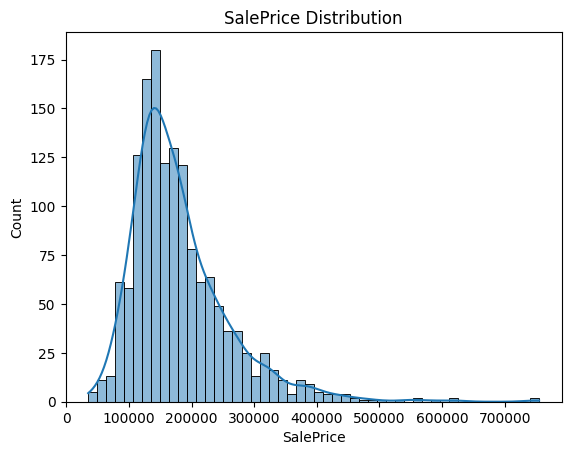

In [ ]:
# Distribution of SalePrice
sns.histplot(df['SalePrice'], bins=50, kde=True)
plt.title("SalePrice Distribution")
plt.show()

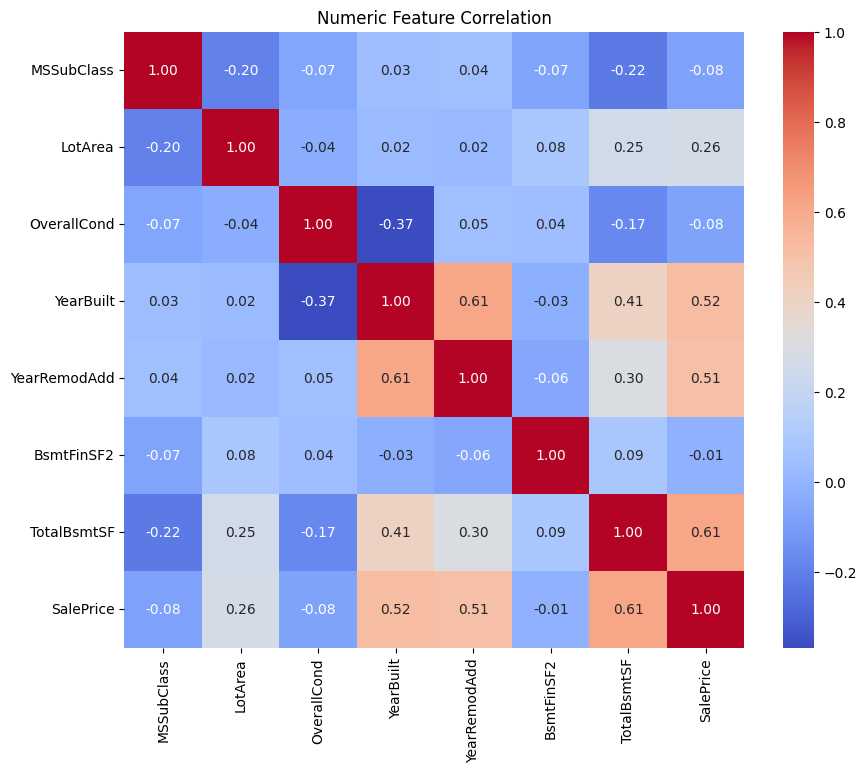

correlation with SalePrice :
 SalePrice       1.000000
TotalBsmtSF     0.613581
YearBuilt       0.522897
YearRemodAdd    0.507101
LotArea         0.263843
BsmtFinSF2     -0.011378
OverallCond    -0.077856
MSSubClass     -0.084284
Name: SalePrice, dtype: float64


In [ ]:
# Correlation Heatmap for numeric features
plt.figure(figsize=(10,8))
sns.heatmap(df.select_dtypes(include=np.number).corr(), annot=True, cmap='coolwarm', fmt=".2f")
plt.title("Numeric Feature Correlation")
plt.show()

# Focus on correlation with SalePrice
corr_matrix = df.select_dtypes(include=np.number).corr()
corr_with_price = corr_matrix['SalePrice'].sort_values(ascending=False)
print("correlation with SalePrice :\n",corr_with_price)

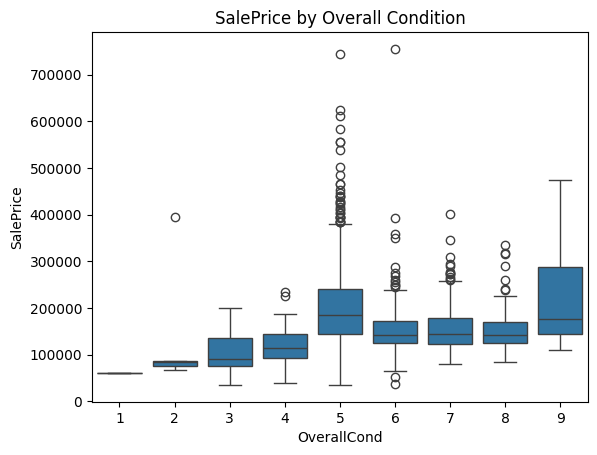

In [ ]:
# Boxplot for LotArea vs SalePrice
sns.boxplot(x='OverallCond', y='SalePrice', data=df)
plt.title("SalePrice by Overall Condition")
plt.show()

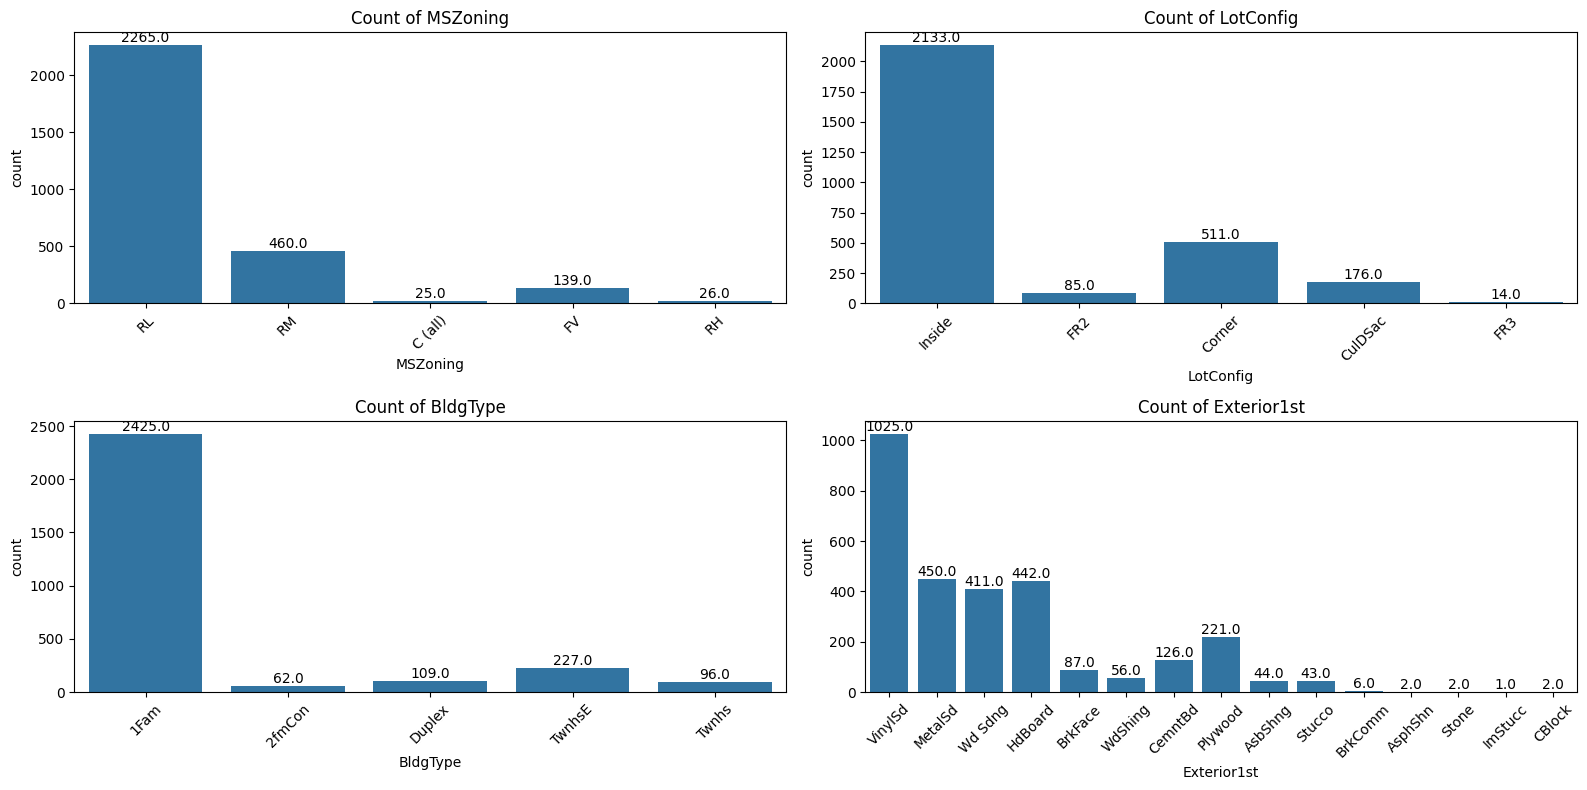

In [ ]:
# Categorical Features
cat_cols = ['MSZoning','LotConfig','BldgType','Exterior1st']

fig, axes = plt.subplots(2, 2, figsize=(16, 8))
axes = axes.flatten()

for i, col in enumerate(cat_cols):
    ax = axes[i]
    sns.countplot(x=col, data=df, ax=ax)
    ax.set_title(f"Count of {col}")
    ax.tick_params(axis='x', rotation=45)

    # Annotate counts on top of bars
    for p in ax.patches:
        height = p.get_height()
        ax.annotate(f'{height}',
                    (p.get_x() + p.get_width() / 2., height),
                    ha='center', va='bottom')

plt.tight_layout()
plt.show()


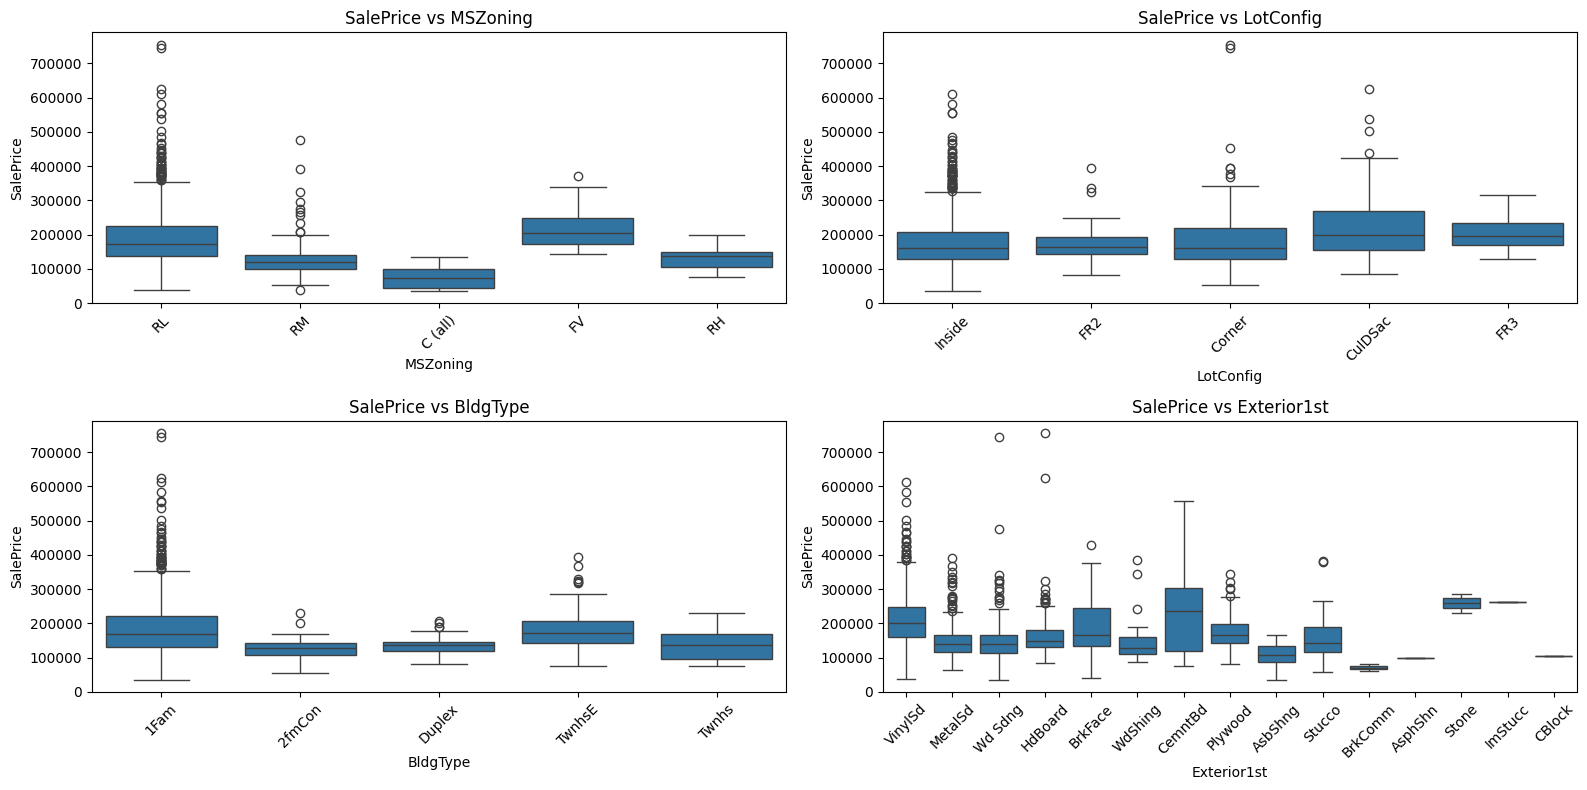

In [ ]:
cat_cols = ['MSZoning','LotConfig','BldgType','Exterior1st']

fig, axes = plt.subplots(2, 2, figsize=(16, 8))

axes = axes.flatten()

for i, col in enumerate(cat_cols):
    sns.boxplot(x=col, y='SalePrice', data=df, ax=axes[i])
    axes[i].set_title(f"SalePrice vs {col}")
    axes[i].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()


# Feature Engineering


In [ ]:
# Has Basement
df['HasBsmt'] = df['TotalBsmtSF'].apply(lambda x: 0 if x==0 else 1)

# Age of house
df['HouseAge'] = 2026 - df['YearBuilt']  # assuming current year 2026

# Years since remodel
df['YearsSinceRemod'] = 2026 - df['YearRemodAdd']

# LotArea log
df['LogLotArea'] = np.log1p(df['LotArea'])

# SalePrice log
df['LogSalePrice'] = np.log1p(df['SalePrice'])

In [ ]:
df

,MSSubClass,MSZoning,LotArea,LotConfig,BldgType,OverallCond,YearBuilt,YearRemodAdd,Exterior1st,BsmtFinSF2,TotalBsmtSF,SalePrice,HasBsmt,HouseAge,YearsSinceRemod,LogLotArea,LogSalePrice
0,60,RL,8450,Inside,1Fam,5,2003,2003,VinylSd,0.0,856.0,208500.0,1,23,23,9.042040,12.247699
1,20,RL,9600,FR2,1Fam,8,1976,1976,MetalSd,0.0,1262.0,181500.0,1,50,50,9.169623,12.109016
2,60,RL,11250,Inside,1Fam,5,2001,2002,VinylSd,0.0,920.0,223500.0,1,25,24,9.328212,12.317171
3,70,RL,9550,Corner,1Fam,5,1915,1970,Wd Sdng,0.0,756.0,140000.0,1,111,56,9.164401,11.849405
4,60,RL,14260,FR2,1Fam,5,2000,2000,VinylSd,0.0,1145.0,250000.0,1,26,26,9.565284,12.429220
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2914,160,RM,1936,Inside,Twnhs,7,1970,1970,CemntBd,0.0,546.0,NaN,1,56,56,7.568896,NaN
2915,160,RM,1894,Inside,TwnhsE,5,1970,1970,CemntBd,0.0,546.0,NaN,1,56,56,7.546974,NaN
2916,20,RL,20000,Inside,1Fam,7,1960,1996,VinylSd,0.0,1224.0,NaN,1,66,30,9.903538,NaN
2917,85,RL,10441,Inside,1Fam,5,1992,1992,HdBoard,0.0,912.0,NaN,1,34,34,9.253591,NaN


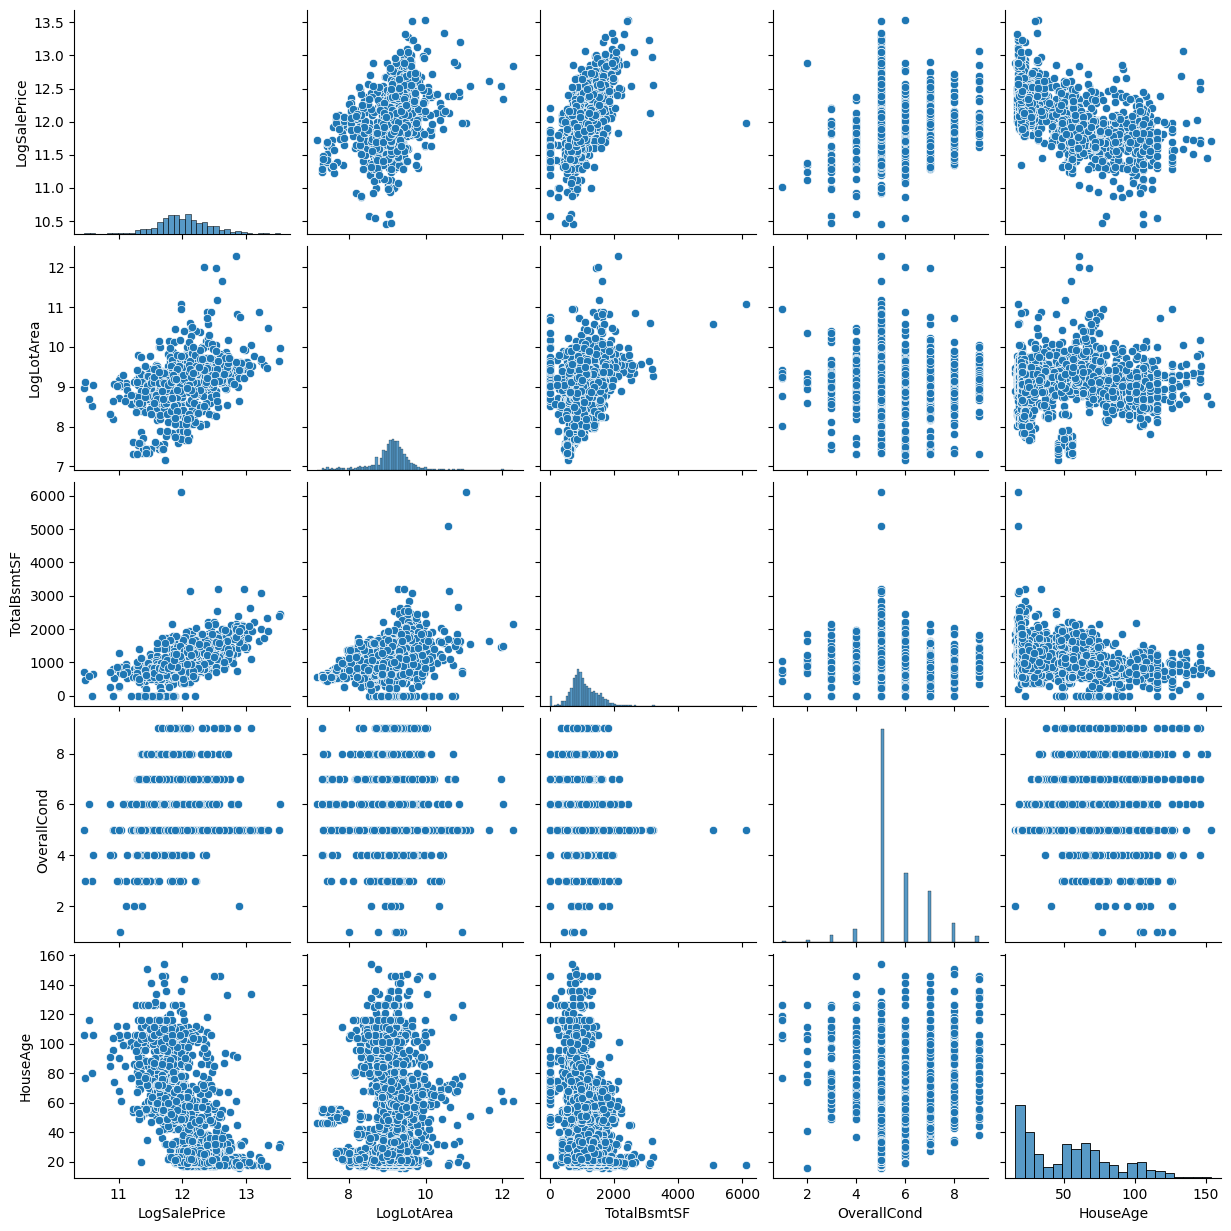

In [ ]:
# Pairplot to see numeric relationships
sns.pairplot(df, vars=['LogSalePrice','LogLotArea','TotalBsmtSF','OverallCond','HouseAge'], kind='scatter')
plt.show()

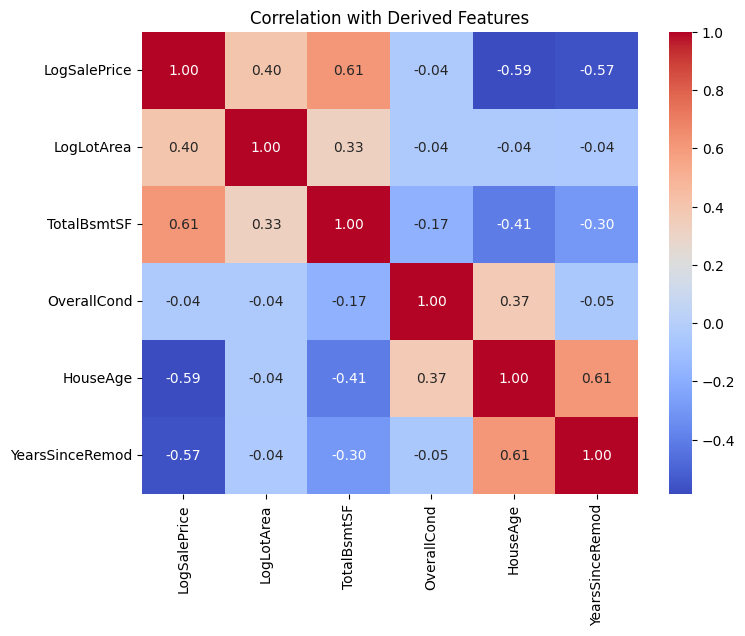

In [ ]:
# Correlation heatmap with derived features
num_cols = ['LogSalePrice','LogLotArea','TotalBsmtSF','OverallCond','HouseAge','YearsSinceRemod']
plt.figure(figsize=(8,6))
sns.heatmap(df[num_cols].corr(), annot=True, cmap='coolwarm', fmt=".2f")
plt.title("Correlation with Derived Features")
plt.show()

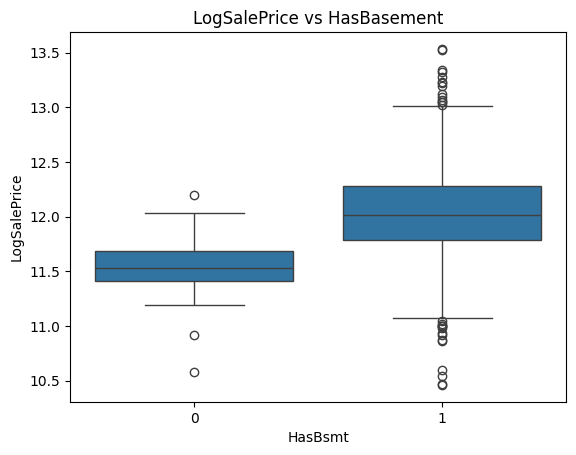

In [ ]:
# Boxplot SalePrice vs HasBsmt
sns.boxplot(x='HasBsmt', y='LogSalePrice', data=df)
plt.title("LogSalePrice vs HasBasement")
plt.show()

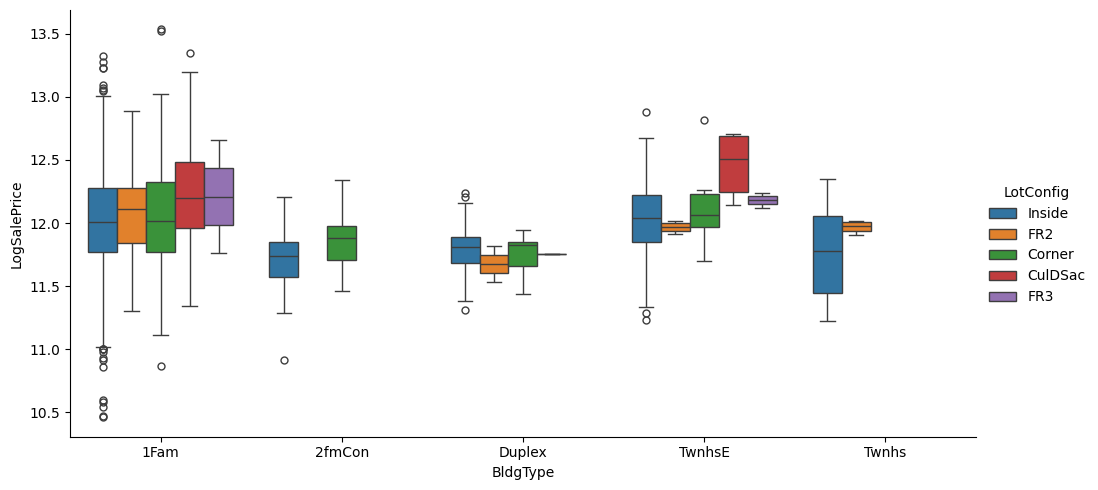

In [ ]:
# SalePrice vs BldgType vs LotConfig
sns.catplot(x='BldgType', y='LogSalePrice', hue='LotConfig', kind='box', data=df, height=5, aspect=2)
plt.show()

# Missing values

In [ ]:
# Categorical Missing Values
df['MSZoning'] = df['MSZoning'].fillna(df['MSZoning'].mode()[0])
df['Exterior1st'] = df['Exterior1st'].fillna(df['Exterior1st'].mode()[0])

In [ ]:
# Numerical Missing Values
df[['BsmtFinSF2', 'TotalBsmtSF']] = df[['BsmtFinSF2', 'TotalBsmtSF']].fillna(0)

In [ ]:
# Check for nulls
df.isnull().sum()

,0
MSSubClass,0
MSZoning,0
LotArea,0
LotConfig,0
BldgType,0
OverallCond,0
YearBuilt,0
YearRemodAdd,0
Exterior1st,0
BsmtFinSF2,0


# Prepare data

In [ ]:
# Train and Test data
train_df = df[df['SalePrice'].notnull()]
test_df = df[df['SalePrice'].isnull()]

X = train_df.drop('SalePrice', axis=1)
y = train_df['SalePrice']

In [ ]:
# split
X_train, X_val, y_train, y_val = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)

In [ ]:
# Numeric & Categorical Columns
num_cols = X_train.select_dtypes(include=['int64','float64']).columns
cat_cols = X_train.select_dtypes(include=['object']).columns

# Linear Regression
**With One Hot encoding**

In [ ]:
# Numerical preprocessing (Scaling)
num_transformer = StandardScaler()

# Categorical preprocessing (Encoding)
cat_transformer = OneHotEncoder(
    handle_unknown='ignore',
    sparse_output=False
)

# Combine them
preprocessor = ColumnTransformer(
    transformers=[
        ('num', num_transformer, num_cols),
        ('cat', cat_transformer, cat_cols)
    ]
)

In [ ]:
# Pipeline = Preprocessing + Model

model = LinearRegression()

pipe = Pipeline(steps=[
    ('preprocessing', preprocessor),
    ('model', model)
])

In [ ]:
# Fit
pipe.fit(X_train, y_train)

# Validation
y_train_pred = pipe.predict(X_train)
y_val_pred   = pipe.predict(X_val)

print("Train MAE:", mean_absolute_error(y_train, y_train_pred))
print("Val MAE:", mean_absolute_error(y_val, y_val_pred))

print("Train RMSE:", np.sqrt(mean_squared_error(y_train, y_train_pred)))
print("Val RMSE:", np.sqrt(mean_squared_error(y_val, y_val_pred)))

print("Train R2:", r2_score(y_train, y_train_pred))
print("Val R2:", r2_score(y_val, y_val_pred))

Train MAE: 12856.614998480234
Val MAE: 14298.74369283761
Train RMSE: 21052.62451060575
Val RMSE: 27638.13119228788
Train R2: 0.9256921359424226
Val R2: 0.900412801858887


In [ ]:
# regularization

# Apply preprocessing to X_train and X_val
X_train_processed = preprocessor.fit_transform(X_train, y_train)
X_val_processed = preprocessor.transform(X_val)

ridge = Ridge(alpha=1.0)  # alpha

ridge.fit(X_train_processed, y_train)

# Predictions
y_train_pred = ridge.predict(X_train_processed)
y_val_pred = ridge.predict(X_val_processed)

print("Train MAE:", mean_absolute_error(y_train, y_train_pred))
print("Val MAE:", mean_absolute_error(y_val, y_val_pred))

print("Train RMSE:", np.sqrt(mean_squared_error(y_train, y_train_pred)))
print("Val RMSE:", np.sqrt(mean_squared_error(y_val, y_val_pred)))

print("Train R2:", r2_score(y_train, y_train_pred))
print("Val R2:", r2_score(y_val, y_val_pred))

Train MAE: 12847.678857390456
Val MAE: 14309.681796218298
Train RMSE: 21065.121300232564
Val RMSE: 27852.769124542607
Train R2: 0.925603891804065
Val R2: 0.8988600058263274


# Linear Regression
**With Target Encoding**

In [ ]:
# Numerical preprocessing (Scaling)
num_transformer = StandardScaler()

# Categorical preprocessing (Encoding)
te = TargetEncoder(cols=cat_cols)

# Combine them
preprocessor = ColumnTransformer(
    transformers=[
        ('num', num_transformer, num_cols),
        ('cat', te, cat_cols)
    ]
)

In [ ]:
# Pipeline = Preprocessing + Model

model = LinearRegression()

pipe = Pipeline(steps=[
    ('preprocessing', preprocessor),
    ('model', model)
])

In [ ]:
# Fit
pipe.fit(X_train, y_train)

# Validation
y_train_pred = pipe.predict(X_train)
y_val_pred   = pipe.predict(X_val)

print("Train MAE:", mean_absolute_error(y_train, y_train_pred))
print("Val MAE:", mean_absolute_error(y_val, y_val_pred))

print("Train RMSE:", np.sqrt(mean_squared_error(y_train, y_train_pred)))
print("Val RMSE:", np.sqrt(mean_squared_error(y_val, y_val_pred)))

print("Train R2:", r2_score(y_train, y_train_pred))
print("Val R2:", r2_score(y_val, y_val_pred))

Train MAE: 13101.277410927922
Val MAE: 14978.115981534327
Train RMSE: 21620.34961291844
Val RMSE: 29629.264728411625
Train R2: 0.921630384920513
Val R2: 0.8855468066633584


In [ ]:
# regularization

# Apply preprocessing to X_train and X_val
X_train_processed = preprocessor.fit_transform(X_train, y_train)
X_val_processed = preprocessor.transform(X_val)

ridge = Ridge(alpha=1.0)  # alpha

ridge.fit(X_train_processed, y_train)

# Predictions
y_train_pred = ridge.predict(X_train_processed)
y_val_pred = ridge.predict(X_val_processed)

print("Train MAE:", mean_absolute_error(y_train, y_train_pred))
print("Val MAE:", mean_absolute_error(y_val, y_val_pred))

print("Train RMSE:", np.sqrt(mean_squared_error(y_train, y_train_pred)))
print("Val RMSE:", np.sqrt(mean_squared_error(y_val, y_val_pred)))

print("Train R2:", r2_score(y_train, y_train_pred))
print("Val R2:", r2_score(y_val, y_val_pred))

Train MAE: 13093.019100055619
Val MAE: 14960.466746264412
Train RMSE: 21620.697619969105
Val RMSE: 29624.4172902943
Train R2: 0.9216278619827629
Val R2: 0.8855842533832307


# Polynomial Regression
**With One Hot Encoding**

In [ ]:
# Preprocessing for numeric + polynomial
num_transformer = Pipeline(steps=[
    ('poly', PolynomialFeatures(include_bias=False)),  # degree will be set in GridSearchCV
    ('scaler', StandardScaler())
])

In [ ]:
# Preprocessor
preprocessor = ColumnTransformer(
    transformers=[
        ('num', num_transformer, num_cols),
        ('cat', OneHotEncoder(handle_unknown='ignore', sparse_output=False), cat_cols)
    ]
)

In [ ]:
# Pipeline: Preprocessing + Ridge
pipe = Pipeline(steps=[
    ('preprocessing', preprocessor),
    ('model', Ridge())
])

In [ ]:
# Grid for alpha and polynomial degree
param_grid = {
    'preprocessing__num__poly__degree': [2, 3],
    'model__alpha': [0.01, 0.1, 1, 10, 100]
}

# GridSearchCV with 5-Fold CV
grid = GridSearchCV(
    pipe,
    param_grid,
    cv=5,
    scoring='neg_mean_absolute_error',  # we want to minimize MAE
    n_jobs=-1
)

In [ ]:
# Fit GridSearch
grid.fit(X_train, y_train)

# Best Parameters
print("Best Parameters:", grid.best_params_)

# Evaluate on Train & Validation sets
y_train_pred = grid.predict(X_train)
y_val_pred   = grid.predict(X_val)

print("Train MAE:", mean_absolute_error(y_train, y_train_pred))
print("Val MAE:", mean_absolute_error(y_val, y_val_pred))

print("Train RMSE:", np.sqrt(mean_squared_error(y_train, y_train_pred)))
print("Val RMSE:", np.sqrt(mean_squared_error(y_val, y_val_pred)))

print("Train R2:", r2_score(y_train, y_train_pred))
print("Val R2:", r2_score(y_val, y_val_pred))

Best Parameters: {'model__alpha': 0.01, 'preprocessing__num__poly__degree': 2}
Train MAE: 2608.0224862961013
Val MAE: 3400.5192767158683
Train RMSE: 4854.397752980479
Val RMSE: 7519.521510088528
Train R2: 0.9960491275882142
Val R2: 0.9926283182470514


In [ ]:
# regularization

# Apply preprocessing to X_train and X_val
X_train_processed = preprocessor.fit_transform(X_train, y_train)
X_val_processed = preprocessor.transform(X_val)

ridge = Ridge(alpha=1.0)  # alpha

ridge.fit(X_train_processed, y_train)

# Predictions
y_train_pred = ridge.predict(X_train_processed)
y_val_pred = ridge.predict(X_val_processed)

print("Train MAE:", mean_absolute_error(y_train, y_train_pred))
print("Val MAE:", mean_absolute_error(y_val, y_val_pred))

print("Train RMSE:", np.sqrt(mean_squared_error(y_train, y_train_pred)))
print("Val RMSE:", np.sqrt(mean_squared_error(y_val, y_val_pred)))

print("Train R2:", r2_score(y_train, y_train_pred))
print("Val R2:", r2_score(y_val, y_val_pred))

Train MAE: 6109.607922848721
Val MAE: 7485.785956858281
Train RMSE: 10856.093493828852
Val RMSE: 15533.179217850788
Train R2: 0.9802407962976603
Val R2: 0.9685437554940243


# Polynomial Regression
**With Target Encoding**

In [ ]:
# Preprocessing for numeric + polynomial
num_transformer = Pipeline(steps=[
    ('poly', PolynomialFeatures(include_bias=False)),  # degree will be set in GridSearchCV
    ('scaler', StandardScaler())
])

In [ ]:
# Preprocessor
preprocessor = ColumnTransformer(
    transformers=[
        ('num', num_transformer, num_cols),
        ('cat', TargetEncoder(cols=cat_cols), cat_cols)
    ]
)

In [ ]:
# Pipeline: Preprocessing + Ridge
pipe = Pipeline(steps=[
    ('preprocessing', preprocessor),
    ('model', Ridge())
])

In [ ]:
# Grid for alpha and polynomial degree
param_grid = {
    'preprocessing__num__poly__degree': [2, 3],
    'model__alpha': [0.01, 0.1, 1, 10, 100]
}

# GridSearchCV with 5-Fold CV
grid = GridSearchCV(
    pipe,
    param_grid,
    cv=5,
    scoring='neg_mean_absolute_error',  # we want to minimize MAE
    n_jobs=-1
)

In [ ]:
# Fit GridSearch
grid.fit(X_train, y_train)

# Best Parameters
print("Best Parameters:", grid.best_params_)

# Evaluate on Train & Validation sets
y_train_pred = grid.predict(X_train)
y_val_pred   = grid.predict(X_val)

print("Train MAE:", mean_absolute_error(y_train, y_train_pred))
print("Val MAE:", mean_absolute_error(y_val, y_val_pred))

print("Train RMSE:", np.sqrt(mean_squared_error(y_train, y_train_pred)))
print("Val RMSE:", np.sqrt(mean_squared_error(y_val, y_val_pred)))

print("Train R2:", r2_score(y_train, y_train_pred))
print("Val R2:", r2_score(y_val, y_val_pred))

Best Parameters: {'model__alpha': 0.01, 'preprocessing__num__poly__degree': 2}
Train MAE: 2642.1755285018257
Val MAE: 3351.4131844386397
Train RMSE: 4958.899760662488
Val RMSE: 7797.037620845183
Train R2: 0.9958771935400695
Val R2: 0.9920741577321821


In [ ]:
# regularization

# Apply preprocessing to X_train and X_val
X_train_processed = preprocessor.fit_transform(X_train, y_train)
X_val_processed = preprocessor.transform(X_val)

ridge = Ridge(alpha=1.0)  # alpha

ridge.fit(X_train_processed, y_train)

# Predictions
y_train_pred = ridge.predict(X_train_processed)
y_val_pred = ridge.predict(X_val_processed)

print("Train MAE:", mean_absolute_error(y_train, y_train_pred))
print("Val MAE:", mean_absolute_error(y_val, y_val_pred))

print("Train RMSE:", np.sqrt(mean_squared_error(y_train, y_train_pred)))
print("Val RMSE:", np.sqrt(mean_squared_error(y_val, y_val_pred)))

print("Train R2:", r2_score(y_train, y_train_pred))
print("Val R2:", r2_score(y_val, y_val_pred))

Train MAE: 6093.832168884779
Val MAE: 7418.655719271909
Train RMSE: 10921.452288985949
Val RMSE: 15871.55524441462
Train R2: 0.9800021606816932
Val R2: 0.9671583373285392


# Polynomial Regression
**With Feature Selection**

In [ ]:
Pipeline([
    ('preprocessing', preprocessor),
    ('feature_selection', SelectKBest(...)),
    ('model', Ridge())
])
X_val_processed   = preprocessor.transform(X_val)

# Feature selection
selector = SelectKBest(score_func=f_regression, k=50)  #  top 50 features
X_train_selected = selector.fit_transform(X_train_processed, y_train)
X_val_selected   = selector.transform(X_val_processed)

ridge = Ridge(alpha=0.01)
ridge.fit(X_train_selected, y_train)

y_train_pred = ridge.predict(X_train_selected)
y_val_pred   = ridge.predict(X_val_selected)

print("Train MAE:", mean_absolute_error(y_train, y_train_pred))
print("Val MAE:", mean_absolute_error(y_val, y_val_pred))
print("Train RMSE:", np.sqrt(mean_squared_error(y_train, y_train_pred)))
print("Val RMSE:", np.sqrt(mean_squared_error(y_val, y_val_pred)))
print("Train R2:", r2_score(y_train, y_train_pred))
print("Val R2:", r2_score(y_val, y_val_pred))

Train MAE: 2969.761024802311
Val MAE: 3747.4332287261254
Train RMSE: 5410.855171579607
Val RMSE: 8407.506539808308
Train R2: 0.9950914399537797
Val R2: 0.9907844641404318


# Model Comparison

## Model Comparison Table

| Model / Encoding / Features | Train MAE | Val MAE | Train RMSE | Val RMSE | Train R² | Val R² | Notes |
|----------------------------|-----------|---------|------------|----------|-----------|--------|-------|
| **Linear Regression + OneHotEncoder** | 12,856 | 14,298 | 21,052 | 27,638 | 0.926 | 0.900 | Baseline linear model, no regularization, simple preprocessing. |
| **Linear Regression + OneHotEncoder + Ridge (α=1.0)** | 12,847 | 14,309 | 21,065 | 27,852 | 0.926 | 0.899 | Ridge added to reduce overfitting; minor effect here. |
| **Linear Regression + Target Encoding** | 13,101 | 14,978 | 21,620 | 29,629 | 0.922 | 0.886 | Target encoding worsened validation performance; may overfit categorical info. |
| **Polynomial Ridge (degree=2) + OneHotEncoder** | 2,608 | 3,400 | 4,854 | 7,519 | 0.996 | 0.993 | Huge improvement, overfitting low due to Ridge. Excellent generalization. |
| **Polynomial Ridge (degree=2) + Target Encoding** | 2,642 | 3,351 | 4,958 | 7,797 | 0.996 | 0.992 | Similar performance to OneHot; TargetEncoder works because polynomial features increase dimensionality. |
| **Polynomial Ridge + Feature Selection (top 50 features)** | 2,969 | 3,747 | 5,410 | 8,407 | 0.995 | 0.991 | Reduced feature complexity, strong generalization, slight reduction in overfitting. |

---

## Key Insights

1. **OneHotEncoder** is suitable for low-cardinality categorical variables.  
2. **TargetEncoder** may overfit if not properly cross-validated.  
3. **Polynomial Features (degree=2)** significantly improve performance when combined with **Ridge regularization**.  
4. **Feature Selection** helps reduce dimensionality while keeping generalization strong.  
5. Proper **Ridge α tuning** is important:
   - Too high → underfitting
   - Too low → slight overfitting
   - Best α here: 0.01 (for polynomial features)  
6. Validation metrics indicate **Polynomial Ridge pipelines** give almost perfect fit (R² ~0.992) without heavy overfitting.

---
